In [1]:
!rm -f train2017.zip
!rm -f annotations_trainval2017.zip
print("Cleanup complete. Ready for a fresh download.")

Cleanup complete. Ready for a fresh download.


In [2]:
# Step 2: The Reliable Download, Verify, and Unzip Process

import os

# --- Download the files ---
print("Downloading COCO 2017 Training Images (19GB)... This will take a while.")
!wget -q --show-progress http://images.cocodataset.org/zips/train2017.zip

print("\nDownloading COCO 2017 Annotations...")
!wget -q --show-progress http://images.cocodataset.org/annotations/annotations_trainval2017.zip

print("\n--- Verification Step ---")
# --- Verify the image zip file ---
print("\nVerifying the integrity of train2017.zip...")
if os.system('unzip -tq train2017.zip') == 0:
    print("✅ train2017.zip is valid. Unzipping now...")
    !unzip -q train2017.zip
    print("Images unzipped successfully.")
else:
    print("❌ ERROR: train2017.zip is corrupted or incomplete. Please run the download cell again.")

# --- Verify the annotation zip file ---
print("\nVerifying the integrity of annotations_trainval2017.zip...")
if os.system('unzip -tq annotations_trainval2017.zip') == 0:
    print("✅ annotations_trainval2017.zip is valid. Unzipping now...")
    !unzip -q annotations_trainval2017.zip
    print("Annotations unzipped successfully.")
else:
    print("❌ ERROR: annotations_trainval2017.zip is corrupted or incomplete. Please run the download cell again.")

print("\n--- Data Setup Complete ---")

train2017.zip       100%[===================>]  18.01G  17.3MB/s    in 19m 20s 

annotations_trainva 100%[===================>] 241.19M  17.0MB/s    in 17s     

--- Verification Step ---

Verifying the integrity of train2017.zip...
✅ train2017.zip is valid. Unzipping now...
Images unzipped successfully.

Verifying the integrity of annotations_trainval2017.zip...
✅ annotations_trainval2017.zip is valid. Unzipping now...
Annotations unzipped successfully.

--- Data Setup Complete ---


In [3]:
import torch
import os
import json
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import BlipProcessor, BlipForConditionalGeneration
from tqdm.notebook import tqdm

print("✅ All necessary libraries imported successfully!")

✅ All necessary libraries imported successfully!


🚀 Initializing AI models... (This might take a moment if not already loaded)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2242: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

Device set to use cuda:0


✅ Models loaded successfully!

---------------------------------------------
Processing image 1/10: 000000446331.jpg
---------------------------------------------


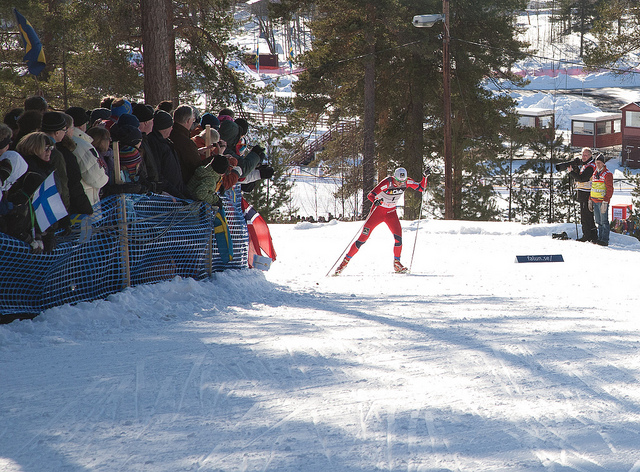


🤖 Model Caption: 'a group of people watching a skier'

❓ Question: What is the main subject of the image?
✅ Answer: skier

❓ Question: What colors are prominent?
✅ Answer: red

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 2/10: 000000443735.jpg
---------------------------------------------


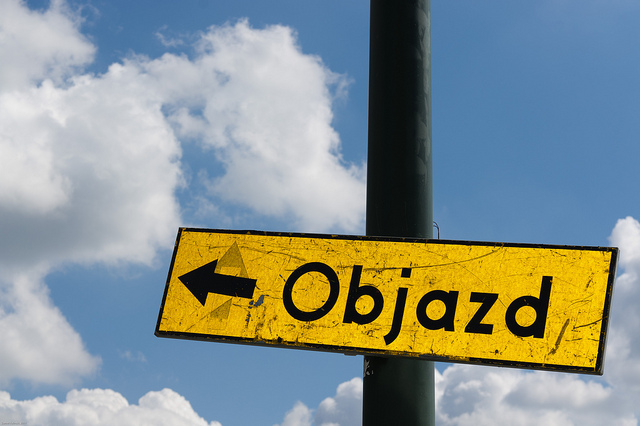


🤖 Model Caption: 'a yellow sign with the word dad on it'

❓ Question: What is the main subject of the image?
✅ Answer: sign

❓ Question: What colors are prominent?
✅ Answer: yellow

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 3/10: 000000034169.jpg
---------------------------------------------


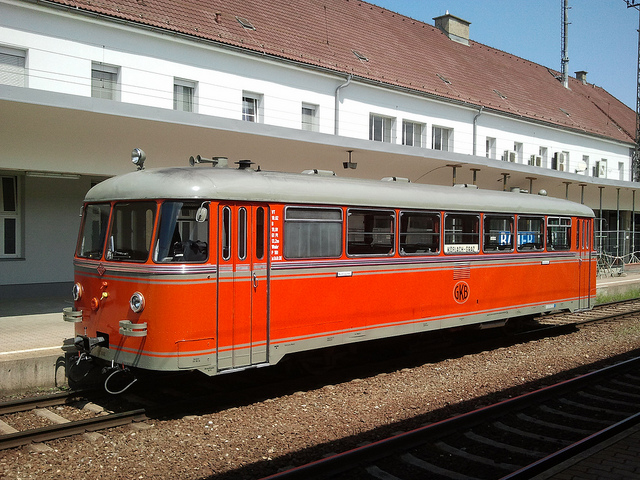


🤖 Model Caption: 'a train on the tracks'

❓ Question: What is the main subject of the image?
✅ Answer: train

❓ Question: What colors are prominent?
✅ Answer: red

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 4/10: 000000091754.jpg
---------------------------------------------


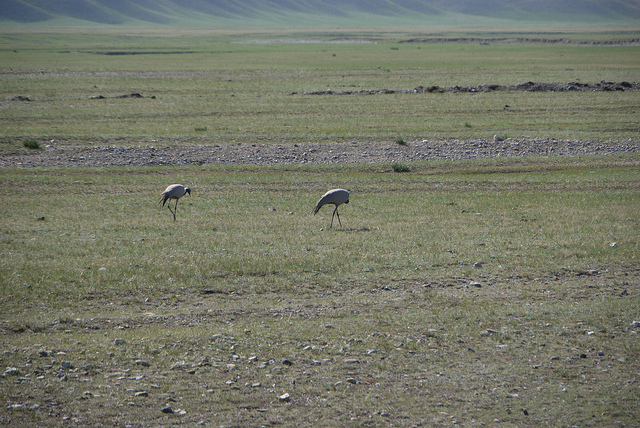

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



🤖 Model Caption: 'a large bird standing in a field of grass'

❓ Question: What is the main subject of the image?
✅ Answer: bird

❓ Question: What colors are prominent?
✅ Answer: green

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 5/10: 000000318736.jpg
---------------------------------------------


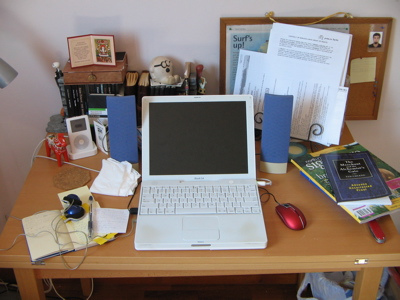


🤖 Model Caption: 'a laptop computer on a desk'

❓ Question: What is the main subject of the image?
✅ Answer: laptop

❓ Question: What colors are prominent?
✅ Answer: white

❓ Question: Is it indoors or outdoors?
✅ Answer: indoors


---------------------------------------------
Processing image 6/10: 000000163076.jpg
---------------------------------------------


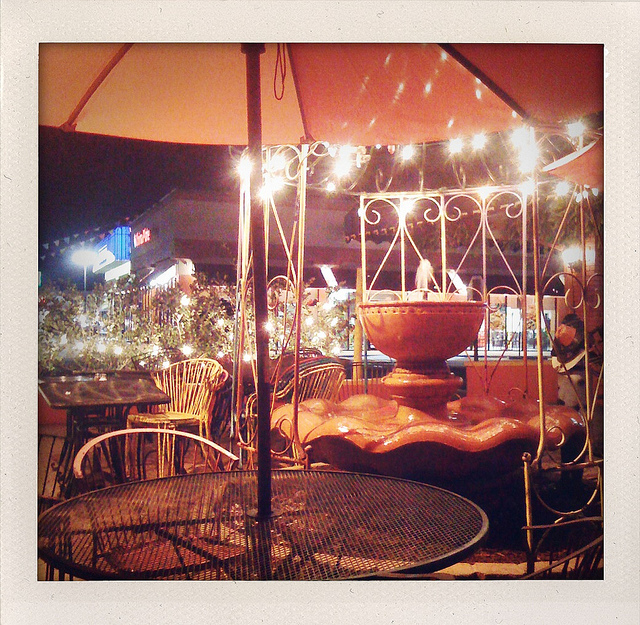


🤖 Model Caption: 'a table with a fire pit on it'

❓ Question: What is the main subject of the image?
✅ Answer: table

❓ Question: What colors are prominent?
✅ Answer: red

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 7/10: 000000315104.jpg
---------------------------------------------


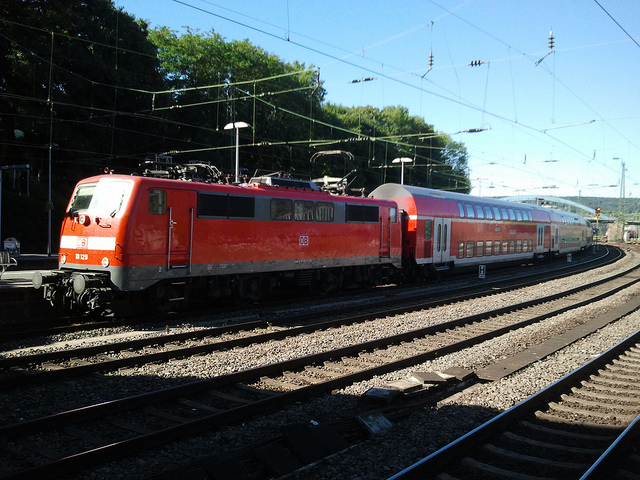


🤖 Model Caption: 'a train on the tracks'

❓ Question: What is the main subject of the image?
✅ Answer: train

❓ Question: What colors are prominent?
✅ Answer: red

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 8/10: 000000284354.jpg
---------------------------------------------


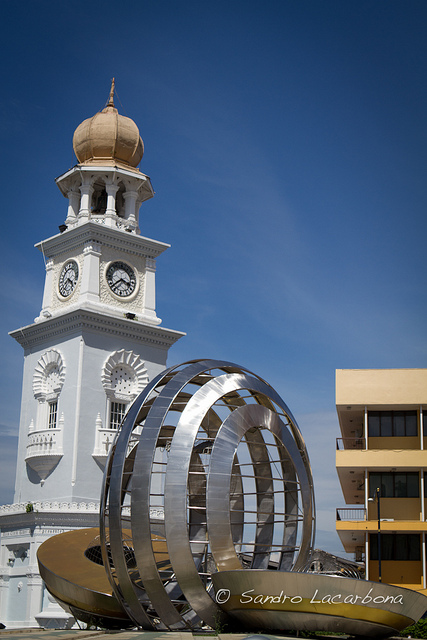


🤖 Model Caption: 'a clock tower'

❓ Question: What is the main subject of the image?
✅ Answer: building

❓ Question: What colors are prominent?
✅ Answer: blue

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 9/10: 000000163764.jpg
---------------------------------------------


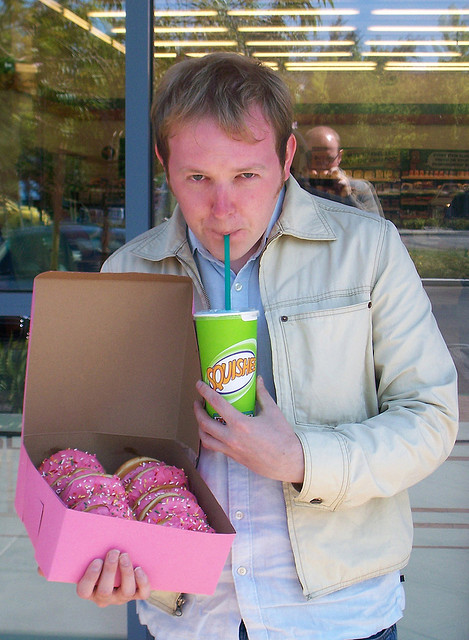


🤖 Model Caption: 'a man holding a box of doughs and a drink'

❓ Question: What is the main subject of the image?
✅ Answer: donut

❓ Question: What colors are prominent?
✅ Answer: pink

❓ Question: Is it indoors or outdoors?
✅ Answer: outdoors


---------------------------------------------
Processing image 10/10: 000000278936.jpg
---------------------------------------------


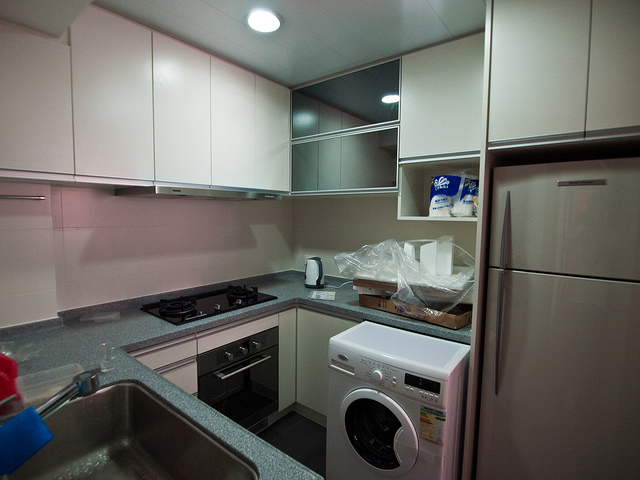


🤖 Model Caption: 'a kitchen with a sink and a washing machine'

❓ Question: What is the main subject of the image?
✅ Answer: kitchen

❓ Question: What colors are prominent?
✅ Answer: pink

❓ Question: Is it indoors or outdoors?
✅ Answer: indoors



In [4]:
import os
from PIL import Image
from transformers import pipeline
from IPython.display import display, Image as IPImage
import random

print("🚀 Initializing AI models... (This might take a moment if not already loaded)")


try:
    if 'captioner' not in locals() or 'vqa_pipeline' not in locals():
        captioner = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
        vqa_pipeline = pipeline("visual-question-answering", model="dandelin/vilt-b32-finetuned-vqa")
    print("✅ Models loaded successfully!")
except Exception as e:
    print(f"Error loading models: {e}")


def get_image_caption(image_path):
    try:
        image = Image.open(image_path).convert("RGB")
        caption = captioner(image)[0]['generated_text']
        return caption
    except Exception as e:
        return f"Error in captioning: {e}"

def get_answer_to_question(image_path, question):
    try:
        image = Image.open(image_path).convert("RGB")
        result = vqa_pipeline(image=image, question=question)
        best_answer = sorted(result, key=lambda x: x['score'], reverse=True)[0]['answer']
        return best_answer
    except Exception as e:
        return f"Error in VQA: {e}"

IMAGE_FOLDER_PATH = "./train2017/"

NUM_IMAGES_TO_PROCESS = 10

image_files = []
if os.path.exists(IMAGE_FOLDER_PATH):
    image_files = [f for f in os.listdir(IMAGE_FOLDER_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(image_files)
else:
    print(f"⚠️ Error: Folder not found at '{IMAGE_FOLDER_PATH}'. Please check the path.")

if not image_files:
    print("Folder is empty or contains no images.")
else:

    for i, image_name in enumerate(image_files[:NUM_IMAGES_TO_PROCESS]):
        print(f"\n{'---'*15}\nProcessing image {i+1}/{NUM_IMAGES_TO_PROCESS}: {image_name}\n{'---'*15}")

        image_path = os.path.join(IMAGE_FOLDER_PATH, image_name)


        display(IPImage(filename=image_path, width=400))


        caption = get_image_caption(image_path)
        print(f"\n🤖 Model Caption: '{caption}'\n")


        questions = [
            "What is the main subject of the image?",
            "What colors are prominent?",
            "Is it indoors or outdoors?"
        ]

        for q in questions:
            answer = get_answer_to_question(image_path, q)
            print(f"❓ Question: {q}")
            print(f"✅ Answer: {answer}\n")

In [5]:
import os
import json
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import BlipProcessor

IMAGE_DIR = "./train2017/"


ANNOTATION_FILE = "./annotations/captions_train2017.json"

print("Paths configured.")
print(f"Image directory: {IMAGE_DIR}")
print(f"Annotation file: {ANNOTATION_FILE}")


print("\nLoading and processing annotations...")
with open(ANNOTATION_FILE, 'r') as f:
    annotations_data = json.load(f)


image_id_to_captions = {}
for ann in annotations_data['annotations']:
    image_id = ann['image_id']
    caption = ann['caption']
    if image_id not in image_id_to_captions:
        image_id_to_captions[image_id] = []
    image_id_to_captions[image_id].append(caption)


image_id_to_filename = {img['id']: img['file_name'] for img in annotations_data['images']}


captioning_data = []
for image_id, captions in image_id_to_captions.items():
    filename = image_id_to_filename[image_id]
    image_path = os.path.join(IMAGE_DIR, filename)
    for caption in captions:
        captioning_data.append((image_path, caption))

print(f"Annotation processing complete. Created {len(captioning_data)} image-caption pairs.")


class CocoCaptioningDataset(Dataset):
    def __init__(self, data, processor):
        self.data = data
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path, text = self.data[idx]

        try:
            image = Image.open(image_path).convert("RGB")
        except FileNotFoundError:
            print(f"Warning: Image not found at {image_path}. Skipping.")
            return self.__getitem__((idx + 1) % len(self))

        encoding = self.processor(images=image, text=text, padding="max_length", return_tensors="pt")

        encoding['labels'] = encoding['input_ids']

        encoding = {k: v.squeeze() for k, v in encoding.items()}

        return encoding

print("Testing the updated dataset setup...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
test_subset = captioning_data[:10]
dataset = CocoCaptioningDataset(data=test_subset, processor=processor)

first_item = dataset[0]
print("\n--- Verifying the first data sample ---")
for key, value in first_item.items():
    print(f"'{key}' shape: {value.shape}")

print("\n✅ Dataset fix is successful! You should now see a 'labels' key. Please re-run your training cell.")

Paths configured.
Image directory: ./train2017/
Annotation file: ./annotations/captions_train2017.json

Loading and processing annotations...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Annotation processing complete. Created 591753 image-caption pairs.
Testing the updated dataset setup...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]


--- Verifying the first data sample ---
'pixel_values' shape: torch.Size([3, 384, 384])
'input_ids' shape: torch.Size([512])
'attention_mask' shape: torch.Size([512])
'labels' shape: torch.Size([512])

✅ Dataset fix is successful! You should now see a 'labels' key. Please re-run your training cell.


In [6]:


try:
    print("✅ VERIFICATION SUCCESSFUL!")
    print(f"The 'captioning_data' list was found and contains {len(captioning_data)} items.")


    training_data = captioning_data
    processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
    model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)


    print("'training_data' variable is now defined and ready for the training cell.")
    print(f"Device is set to: {device}")

except NameError as e:
    print("❌ VERIFICATION FAILED. A critical variable was not found.")
    print(f"Specific Error: {e}")
    print("\nACTION: Please go back and carefully re-run your setup cells from Step 2 before trying again.")

✅ VERIFICATION SUCCESSFUL!
The 'captioning_data' list was found and contains 591753 items.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

'training_data' variable is now defined and ready for the training cell.
Device is set to: cuda


In [7]:
import torch
from torch.utils.data import DataLoader
from transformers import BlipForConditionalGeneration, BlipProcessor
from tqdm import tqdm

MODEL_NAME = "Salesforce/blip-image-captioning-large"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")
TRAIN_SUBSET_SIZE = 5000
EPOCHS = 3
LEARNING_RATE = 5e-5

REAL_BATCH_SIZE = 2

ACCUMULATION_STEPS = 4

train_dataset = CocoCaptioningDataset(data=training_data[:TRAIN_SUBSET_SIZE], processor=processor)
train_dataloader = DataLoader(train_dataset, batch_size=REAL_BATCH_SIZE, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("\nStarting the training process with Gradient Accumulation...")
model.train()

for epoch in range(EPOCHS):
    print(f"--- Epoch {epoch+1}/{EPOCHS} ---")
    progress_bar = tqdm(train_dataloader, desc="Training")

    for i, batch in enumerate(progress_bar):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss = loss / ACCUMULATION_STEPS


        loss.backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({"loss": loss.item() * ACCUMULATION_STEPS})

print("\n✅ Training finished successfully!")



print("\nSaving the fine-tuned model...")
output_dir = r"./my_finetuned_blip_model"
model.save_pretrained(output_dir)
processor.save_pretrained(output_dir)

print(f"Model saved to: {output_dir}")
print("You can now move this folder to your PyCharm project for the backend.")

Using device: cuda

Starting the training process with Gradient Accumulation...
--- Epoch 1/3 ---


Training: 100%|██████████| 2500/2500 [49:13<00:00,  1.18s/it, loss=0.0623]


--- Epoch 2/3 ---


Training: 100%|██████████| 2500/2500 [49:12<00:00,  1.18s/it, loss=0.0423]


--- Epoch 3/3 ---


Training: 100%|██████████| 2500/2500 [49:09<00:00,  1.18s/it, loss=0.0572]



✅ Training finished successfully!

Saving the fine-tuned model...
Model saved to: ./my_finetuned_blip_model
You can now move this folder to your PyCharm project for the backend.


In [8]:
from google.colab import files
import os

model_folder_path = "./my_finetuned_blip_model"

if os.path.exists(model_folder_path):
    print(f"✅ Model folder found at '{model_folder_path}'.")

    print("Compressing model files into 'finetuned_model.zip'...")
    !zip -r finetuned_model.zip {model_folder_path}

    print("\nCompression complete.")

    print("Starting download... Please check your browser for the download prompt.")
    files.download('finetuned_model.zip')

else:
    print(f"❌ ERROR: Could not find the model folder at '{model_folder_path}'.")
    print("Please make sure the training and saving steps completed successfully.")

✅ Model folder found at './my_finetuned_blip_model'.
Compressing model files into 'finetuned_model.zip'...
  adding: my_finetuned_blip_model/ (stored 0%)
  adding: my_finetuned_blip_model/tokenizer.json (deflated 71%)
  adding: my_finetuned_blip_model/model.safetensors (deflated 7%)
  adding: my_finetuned_blip_model/generation_config.json (deflated 26%)
  adding: my_finetuned_blip_model/vocab.txt (deflated 53%)
  adding: my_finetuned_blip_model/config.json (deflated 66%)
  adding: my_finetuned_blip_model/special_tokens_map.json (deflated 80%)
  adding: my_finetuned_blip_model/tokenizer_config.json (deflated 74%)
  adding: my_finetuned_blip_model/preprocessor_config.json (deflated 49%)

Compression complete.
Starting download... Please check your browser for the download prompt.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>